In [1]:
import numpy as np
import os,sys,glob
from pathlib import Path
import logging
from helper import (filterObjects,getModelInfo,saveOutput, \
                    electron_reco, muon_reco, deltaR, cutFlow, getD0,ee_acceptance,mm_acceptance,em_acceptance)

from computeEfficiencies import getSR,preSelection,getObjects
DelphesLLP_path = Path(os.path.abspath("./DelphesLLP"))
os.environ['ROOT_INCLUDE_PATH'] = os.path.join(DelphesLLP_path,"external")

import ROOT
ROOT.gSystem.Load(os.path.join(DelphesLLP_path,"libDelphes.so"))
ROOT.gInterpreter.Declare('#include "classes/SortableObject.h"')
ROOT.gInterpreter.Declare('#include "classes/DelphesClasses.h"')
ROOT.gInterpreter.Declare('#include "external/ExRootAnalysis/ExRootTreeReader.h"')
from ROOT import TFile,Electron, Jet, MissingET, Muon, TTree
# Cosmetics:
import matplotlib.pyplot as plt

import seaborn as sns
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']
cm_rev = plt.colormaps['RdYlBu_r']

Welcome to JupyROOT 6.30/06


In [ ]:
inputFile = './pp2selsel/Events/run_09/selectron_400GeV_1.000ns_delphes_events.root'
# inputFile = './pp2selsel_scan/Events/run_35/selectron_425GeV_3.160ns_delphes_events.root'

f = TFile(inputFile,'read')
DelphesTree = f.Get('Delphes')
nevts = DelphesTree.GetEntries()

totalweight = 0
ct=0

d0A = []
d0B = []
pTA = []
pTB = []
effA = []
effB = []
for entry in range(nevts):
    DelphesTree.GetEntry(entry)
    ct+=1

    weight = float(DelphesTree.Weight.At(0).Weight)    
    totalweight += weight
    _,muons,electrons = getObjects(DelphesTree)
    leptons_preSel = preSelection(muons,electrons)
    if not leptons_preSel:
        continue
    if any(lep.PT < 65. for lep in leptons_preSel):
        continue
    if any(abs(lep.D0) < 3. for lep in leptons_preSel):
        continue
    # if any(abs(lep.D0) > 300. for lep in leptons_preSel):
        # continue
    if len(leptons_preSel) < 2:
        continue
    if any(abs(lep.PID) != 11 for lep in leptons_preSel):
        continue
    if deltaR(leptons_preSel[0], leptons_preSel[1]) < 0.2:
            continue

    eff_reco_A = electron_reco.efficiency(Lepton_p_textT_GeV=leptons_preSel[0].PT, 
                                    Lepton_d_0_mm=abs(leptons_preSel[0].D0))
    eff_reco_B = electron_reco.efficiency(Lepton_p_textT_GeV=leptons_preSel[1].PT, 
                                    Lepton_d_0_mm=abs(leptons_preSel[1].D0))

    # if eff_reco_A == 0. or eff_reco_B == 0.:
    #     print(f"eff A = {eff_reco_A}, eff B = {eff_reco_B}")
    #     print(f"pT A = {leptons_preSel[0].PT}, d0 A = {leptons_preSel[0].D0}")
    #     print(f"pT B = {leptons_preSel[1].PT}, d0 B = {leptons_preSel[1].D0}")
    #     break
    d0A.append(abs(leptons_preSel[0].D0))
    d0B.append(abs(leptons_preSel[1].D0))
    pTA.append(leptons_preSel[0].PT)
    pTB.append(leptons_preSel[1].PT)
    effA.append(eff_reco_A)
    effB.append(eff_reco_B)

In [ ]:
# Efficiency edges from ATLAS
edges = np.array([[65.,300.],[135.,300.],[205.,300.],[205.,250.],[275.,250.],[345.,250.],[345.,200.],[415.,200.],[415.,150.],[485.,150.],[555.,150.],[555.,100.],[770.,100.]])

In [ ]:
nA_fail = 0
nB_fail = 0
for pA,dA in zip(pTA,d0A):
    i = np.searchsorted(edges[:,0], pA)
    if i == len(edges):
        d0max = 0.0
    else:
        d0max = edges[:,1][i]
    if dA > d0max:
        nA_fail += 1
print(f"Fractions of failed entries for leading lepton: {float(nA_fail)/len(pTA):.2f} ({nA_fail} out of {len(pTA)})")

for pB,dB in zip(pTB,d0B):
    i = np.searchsorted(edges[:,0], pB)
    if i == len(edges):
        d0max = 0.0
    else:
        d0max = edges[:,1][i]
    if dB > d0max:
        nB_fail += 1
print(f"Fractions of failed entries for subleading lepton: {float(nB_fail)/len(pTB):.2f} ({nB_fail} out of {len(pTB)})")


Fractions of failed entries for leading lepton: 0.21 (4643 out of 21669)
Fractions of failed entries for subleading lepton: 0.19 (4216 out of 21669)


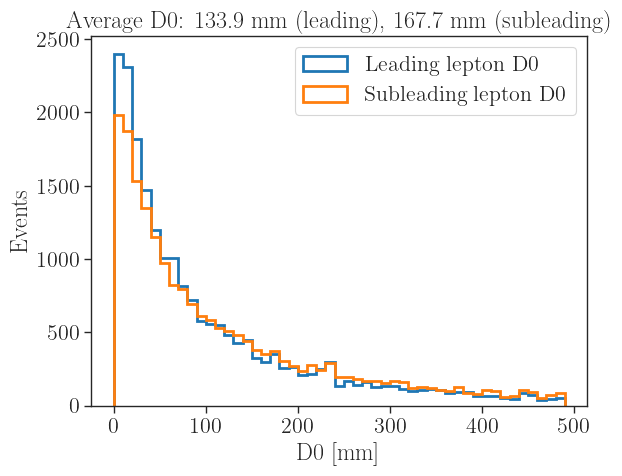

In [ ]:
plt.hist(d0A,bins=np.arange(0,500,10),histtype='step',label='Leading lepton D0',linewidth=2)
plt.hist(d0B,bins=np.arange(0,500,10),histtype='step',label='Subleading lepton D0',linewidth=2)
plt.xlabel('D0 [mm]')
plt.ylabel('Events')
plt.title(f'Average D0: {np.mean(d0A):.1f} mm (leading), {np.mean(d0B):.1f} mm (subleading)')
plt.legend()
plt.show()

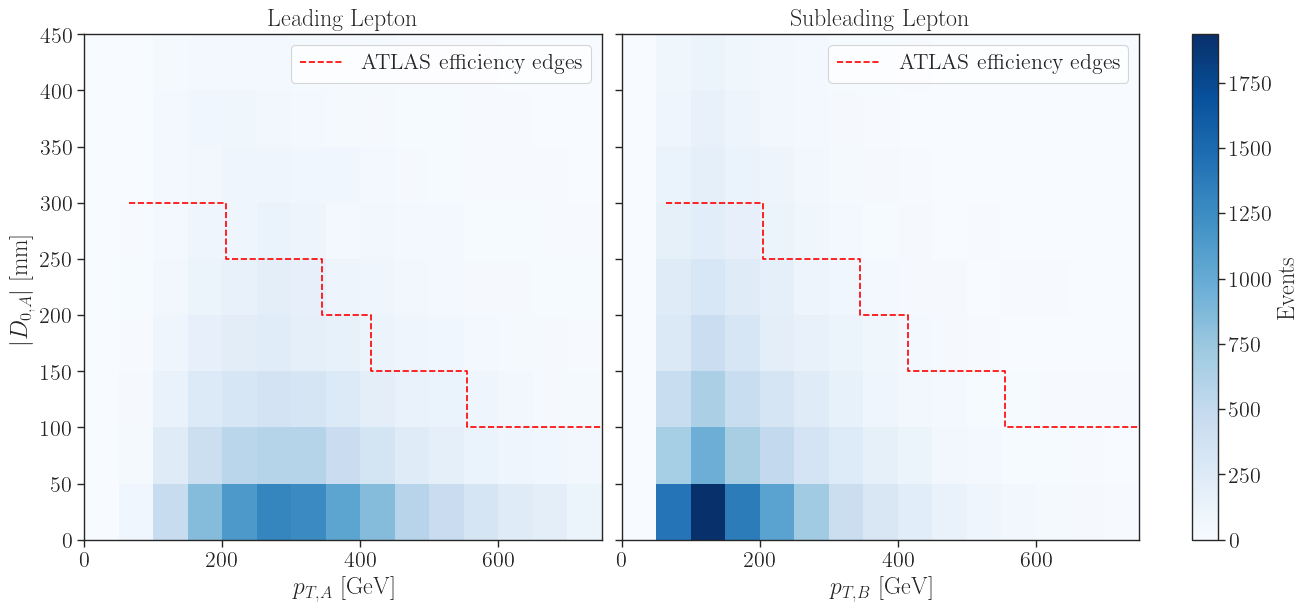

In [ ]:
if pTA and d0A and pTB and d0B:
    xbins = np.arange(0, 800., 50.)
    ybins = np.arange(0, 500, 50.)

    fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True, constrained_layout=True)

    hist_a = axes[0].hist2d(pTA, d0A, bins=[xbins, ybins], cmap='Blues')
    axes[0].set_xlabel(r'$p_{T,A}$ [GeV]')
    axes[0].set_ylabel(r'$|D_{0,A}|$ [mm]')
    axes[0].set_title('Leading Lepton')


    hist_b = axes[1].hist2d(pTB, d0B, bins=[xbins, ybins], cmap='Blues')
    axes[1].set_xlabel(r'$p_{T,B}$ [GeV]')
    axes[1].set_title('Subleading Lepton')

    axes[0].plot(edges[:,0], edges[:,1], color='red', linestyle='--', label='ATLAS efficiency edges')
    axes[0].legend()
    axes[1].plot(edges[:,0], edges[:,1], color='red', linestyle='--', label='ATLAS efficiency edges')
    axes[1].legend()

    vmax = max(hist_a[0].max(), hist_b[0].max())
    hist_a[3].set_clim(0, vmax)
    hist_b[3].set_clim(0, vmax)
    fig.colorbar(hist_a[3], ax=axes, label='Events')
    plt.show()
else:
    print('No entries available for the 2D histogram yet.')

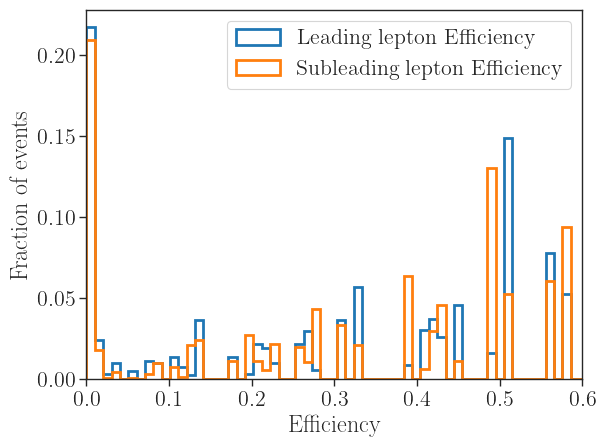

In [ ]:
plt.hist(effA,bins=np.linspace(0,1,100),histtype='step',label='Leading lepton Efficiency',linewidth=2,weights=np.ones_like(effA)/len(effA))
plt.hist(effB,bins=np.linspace(0,1,100),histtype='step',label='Subleading lepton Efficiency',linewidth=2,weights=np.ones_like(effB)/len(effB))
plt.xlabel('Efficiency')
plt.ylabel('Fraction of events')
plt.xlim(0.,0.6)
plt.legend()
plt.show()

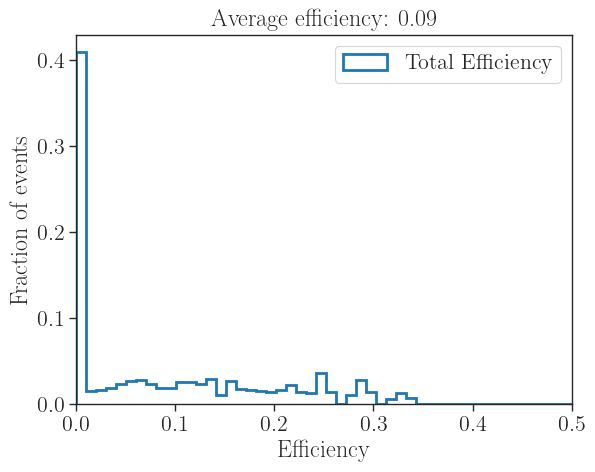

In [ ]:
effTot = [eA*eB for eA,eB in zip(effA,effB)]
plt.hist(effTot,bins=np.linspace(0,1,100),histtype='step',label='Total Efficiency',linewidth=2,weights=np.ones_like(effA)/len(effA))
plt.xlabel('Efficiency')
plt.ylabel('Fraction of events')
plt.xlim(0.,0.5)
plt.legend()
plt.title('Average efficiency: {:.2f}%'.format(np.mean(effTot)))
plt.show()